# Predicting Price with Size, Location, and Neighborhood

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from glob import glob
from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted


## Prepare Data

### import

In [2]:
files = glob("C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires/buenos-aires-real-estate-*.csv")
files

['C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires\\buenos-aires-real-estate-1.csv',
 'C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires\\buenos-aires-real-estate-2.csv',
 'C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires\\buenos-aires-real-estate-3.csv',
 'C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires\\buenos-aires-real-estate-4.csv',
 'C:/Users/x/Desktop/data_projects/Housing-in-Buenos-Aires\\buenos-aires-real-estate-5.csv']

In [3]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
    return df

In [4]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)


(8606, 16)
(8606, 16)
(8606, 16)
(8606, 16)
(8605, 16)


In [5]:
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

df shape: (43029, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


In [6]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    return df

In [7]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames)
print("df shape:", df.shape)
df.head()

(1781, 16)
(1777, 16)
(1749, 16)
(1731, 16)
(1736, 16)
df shape: (8774, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
1,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
5,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
10,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
12,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
21,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


In [8]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    return df

In [9]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames)
print("df shape:", df.shape)
df.head()

(1781, 17)
(1777, 17)
(1749, 17)
(1731, 17)
(1736, 17)
df shape: (8774, 17)


,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon
1,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...,-34.604783,-58.458681
5,sell,apartment,|Argentina|Capital Federal|Chacarita|,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693
10,sell,apartment,|Argentina|Capital Federal|Villa Luro|,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115
12,sell,apartment,|Argentina|Capital Federal|Once|,60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...,-34.605006,-58.400116
21,sell,apartment,|Argentina|Capital Federal|San Nicolás|,69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...,-34.603898,-58.378617


In [10]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)

    return df

In [11]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames)
print("df shape:", df.shape)
df.head()

(1781, 17)
(1777, 17)
(1749, 17)
(1731, 17)
(1736, 17)
df shape: (8774, 17)


,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighborhood
1,sell,apartment,180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...,-34.604783,-58.458681,Villa Crespo
5,sell,apartment,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693,Chacarita
10,sell,apartment,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115,Villa Luro
12,sell,apartment,60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...,-34.605006,-58.400116,Once
21,sell,apartment,69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...,-34.603898,-58.378617,San Nicolás


### explor

#### Size

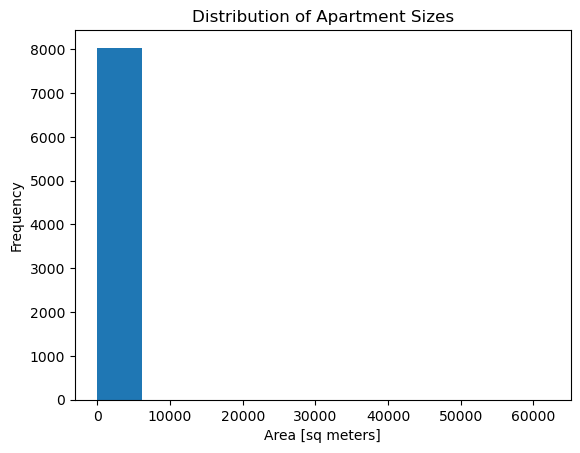

In [12]:
# histogram of "surface_covered_in_m2"
df['surface_covered_in_m2'].plot(kind="hist")
# x-axis label
plt.xlabel("Area [sq meters]")

# y-axis label
plt.ylabel("Frequency")

# title
plt.title("Distribution of Apartment Sizes");

In [13]:
df['surface_covered_in_m2'].describe()

count     8036.000000
mean        67.410154
std        697.311110
min          0.000000
25%         37.000000
50%         49.000000
75%         72.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

In [14]:
df['surface_covered_in_m2'].dropna().sort_values()

3834        0.0
8231        0.0
7565        0.0
2433        0.0
2475        0.0
         ...   
8574      300.0
5745      605.0
4118     2105.0
5613     7415.0
3104    62034.0
Name: surface_covered_in_m2, Length: 8036, dtype: float64

In [15]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)
# Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    return df

In [16]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

(1343, 17)
(1315, 17)
(1288, 17)
(1305, 17)
(1331, 17)
df shape: (6582, 17)


,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighborhood
0,sell,apartment,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693,Chacarita
1,sell,apartment,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115,Villa Luro
2,sell,apartment,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957,Caballito
3,sell,apartment,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382,Constitución
4,sell,apartment,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511,Once


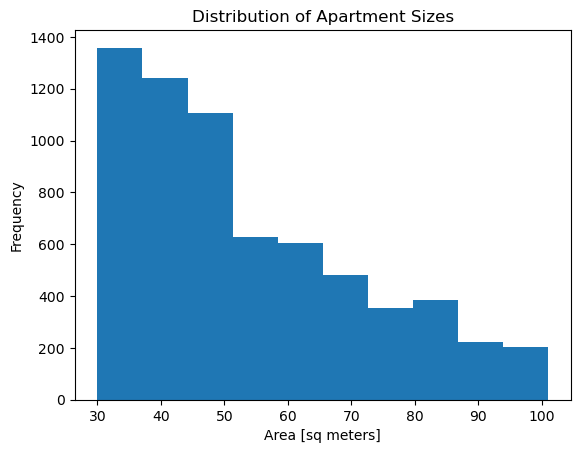

In [17]:
# create histogram of "surface_covered_in_m2"
df['surface_covered_in_m2'].plot(kind="hist")
# Add x-axis label
plt.xlabel("Area [sq meters]")

# Add y-axis label
plt.ylabel("Frequency")

# Add title
plt.title("Distribution of Apartment Sizes");

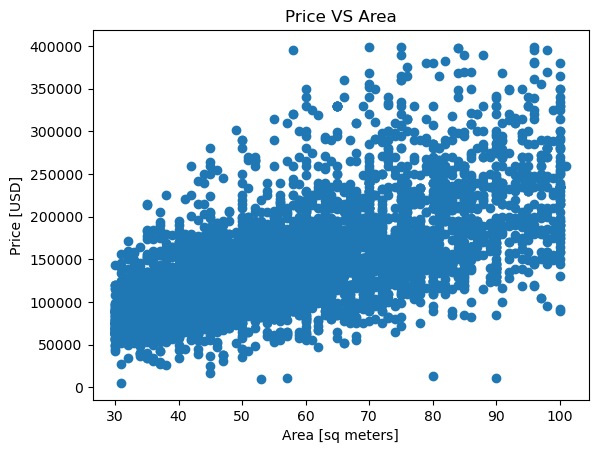

In [18]:
# scatter plot of "price_aprox_usd" vs "surface_covered_in_m2"
plt.scatter(df['surface_covered_in_m2'],df['price_aprox_usd'])

# Add x-axis label
plt.xlabel("Area [sq meters]")
# Add y-axis label
plt.ylabel("Price [USD]")
# Add title
plt.title("Price VS Area");

#### Longitude & latitude

C:\Users\x\AppData\Local\Temp\ipykernel_11148\2607441933.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


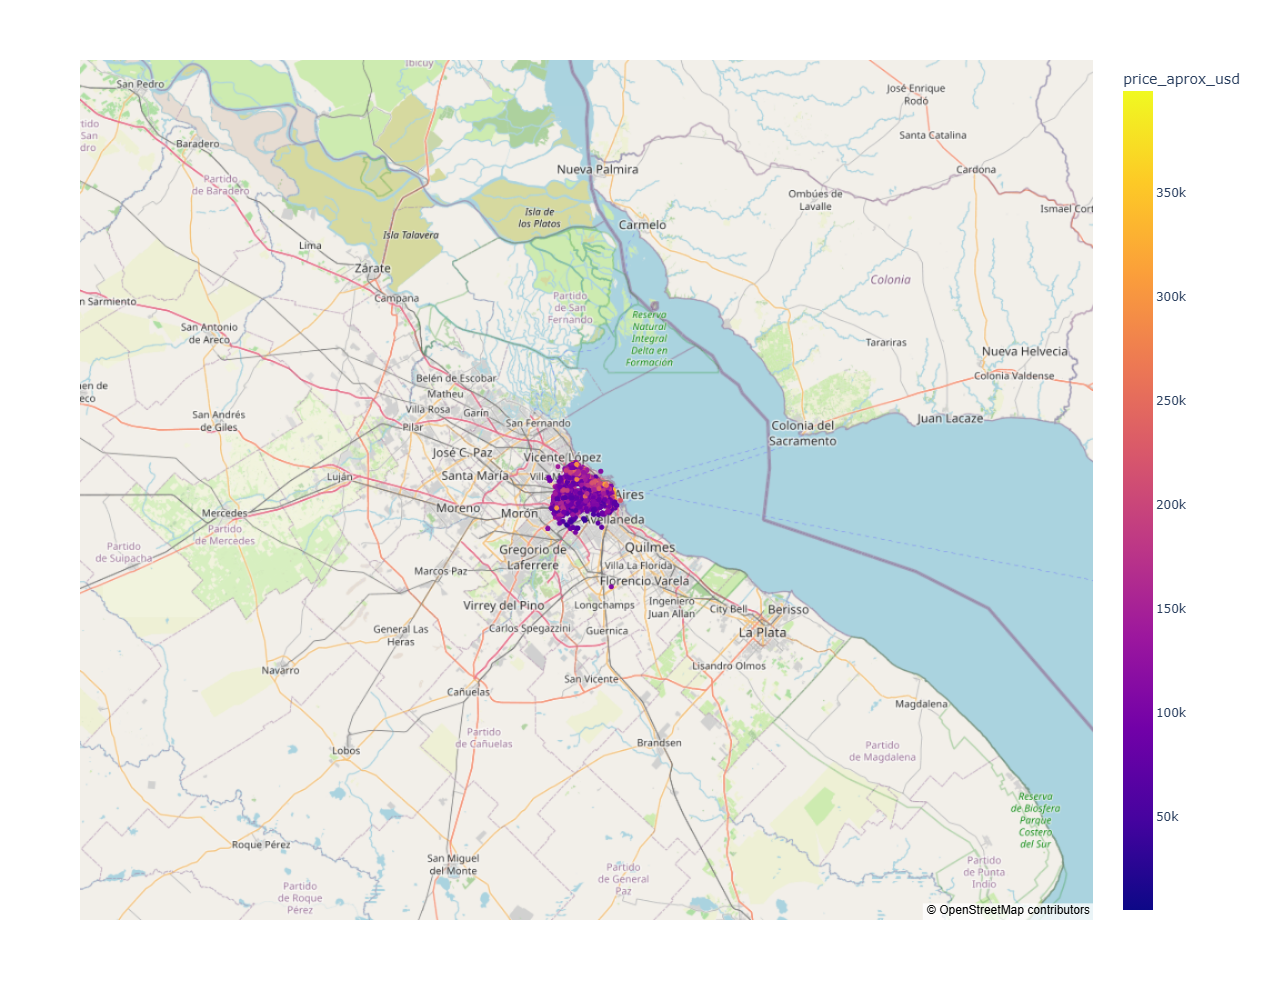

In [19]:
fig = px.scatter_mapbox(
    df,  # Our DataFrame
    lat= "lat",
    lon= "lon",
    width=1000,  # Width of map
    height=1000,  # Height of map
    color= "price_aprox_usd",
    hover_data=["price_aprox_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

### Missing values

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   6582 non-null   object 
 1   property_type               6582 non-null   object 
 2   price                       6582 non-null   float64
 3   currency                    6582 non-null   object 
 4   price_aprox_local_currency  6582 non-null   float64
 5   price_aprox_usd             6582 non-null   float64
 6   surface_total_in_m2         4752 non-null   float64
 7   surface_covered_in_m2       6582 non-null   float64
 8   price_usd_per_m2            4536 non-null   float64
 9   price_per_m2                6582 non-null   float64
 10  floor                       1900 non-null   float64
 11  rooms                       5286 non-null   float64
 12  expenses                    1739 non-null   object 
 13  properati_url               6582 

In [21]:
df.isnull().sum()/len(df)>0.5

operation                     False
property_type                 False
price                         False
currency                      False
price_aprox_local_currency    False
price_aprox_usd               False
surface_total_in_m2           False
surface_covered_in_m2         False
price_usd_per_m2              False
price_per_m2                  False
floor                          True
rooms                         False
expenses                       True
properati_url                 False
lat                           False
lon                           False
neighborhood                  False
dtype: bool

In [22]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)
# Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]
#drop columns with over 50% NAN values 
   
    df = df.loc[:, df.isnull().mean() <= 0.5]  


    return df


In [23]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

(1343, 15)
(1315, 15)
(1288, 15)
(1305, 15)
(1331, 15)
df shape: (6582, 15)


,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,rooms,properati_url,lat,lon,neighborhood
0,sell,apartment,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693,Chacarita
1,sell,apartment,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115,Villa Luro
2,sell,apartment,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,2.0,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957,Caballito
3,sell,apartment,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,2.0,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382,Constitución
4,sell,apartment,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,3.0,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511,Once


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   6582 non-null   object 
 1   property_type               6582 non-null   object 
 2   price                       6582 non-null   float64
 3   currency                    6582 non-null   object 
 4   price_aprox_local_currency  6582 non-null   float64
 5   price_aprox_usd             6582 non-null   float64
 6   surface_total_in_m2         4752 non-null   float64
 7   surface_covered_in_m2       6582 non-null   float64
 8   price_usd_per_m2            4536 non-null   float64
 9   price_per_m2                6582 non-null   float64
 10  rooms                       5286 non-null   float64
 11  properati_url               6582 non-null   object 
 12  lat                         6316 non-null   float64
 13  lon                         6316 

### Cardinality

In [25]:
df.select_dtypes(object).nunique()

operation           1
property_type       1
currency            2
properati_url    6582
neighborhood       57
dtype: int64

In [26]:

def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)
# Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]
#drop columns with over 50% NAN values 
   
    df = df.loc[:, df.isnull().mean() <= 0.5]  

#Drop columns containing low- or high-cardinality categorical values.
    nunique = df.nunique()
    df = df.loc[:, (nunique > 2) & (nunique < len(df))]

    return df


In [27]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

(1343, 11)
(1315, 11)
(1288, 11)
(1305, 11)
(1331, 11)
df shape: (6582, 11)


,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,rooms,lat,lon,neighborhood
0,129000.0,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,-34.584651,-58.454693,Chacarita
1,87000.0,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,-34.638979,-58.500115,Villa Luro
2,118000.0,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,2.0,-34.615847,-58.459957,Caballito
3,57000.0,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,2.0,-34.625222,-58.382382,Constitución
4,90000.0,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,3.0,-34.610610,-58.412511,Once


### leakage

In [28]:

def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)
# Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]
#drop columns with over 50% NAN values 
   
    df = df.loc[:, df.isnull().mean() <= 0.5]  

#Drop columns containing low- or high-cardinality categorical values.
    nunique = df.nunique()
    df = df.loc[:, (nunique > 2) & (nunique < len(df))]

#Drop any columns that would constitute leakage for the target "price_aprox_usd".
    columns_leakage=["price","price_aprox_local_currency","price_per_m2","price_usd_per_m2"]
    df.drop(columns=columns_leakage,inplace=True)

    return df


In [29]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

(1343, 7)
(1315, 7)
(1288, 7)
(1305, 7)
(1331, 7)
df shape: (6582, 7)


,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,rooms,lat,lon,neighborhood
0,129000.0,76.0,70.0,NaN,-34.584651,-58.454693,Chacarita
1,87000.0,48.0,42.0,NaN,-34.638979,-58.500115,Villa Luro
2,118000.0,NaN,54.0,2.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,42.0,2.0,-34.625222,-58.382382,Constitución
4,90000.0,57.0,50.0,3.0,-34.610610,-58.412511,Once


### Multicollinearity

<Axes: >

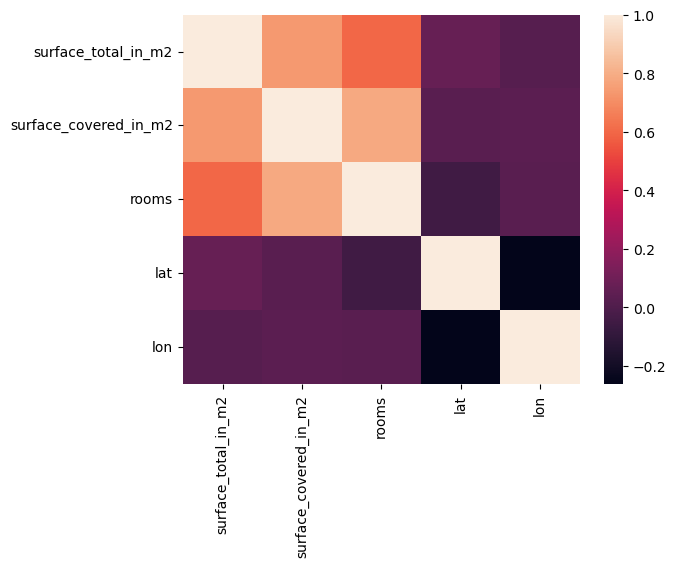

In [30]:
corr = df.drop(columns=["price_aprox_usd","neighborhood"]).corr()
sns.heatmap(corr)


In [31]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath,sep=";",index_col=0)
# Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]
# Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
#create "neighborhood" feature 
    df["neighborhood"]=df['place_with_parent_names'].str.split("|",expand=True)[3]
    df.drop(columns="place_with_parent_names",inplace=True)
# Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]
#drop columns with over 50% NAN values 
   
    df = df.loc[:, df.isnull().mean() <= 0.5]  

#Drop columns containing low- or high-cardinality categorical values.
    nunique = df.nunique()
    df = df.loc[:, (nunique > 2) & (nunique < len(df))]

#Drop any columns that would constitute leakage for the target "price_aprox_usd".
    columns_leakage=["price","price_aprox_local_currency","price_per_m2","price_usd_per_m2"]
    df.drop(columns=columns_leakage,inplace=True)

#Drop columns that are strongly correlated in our feature matrix
    df.drop(columns=["rooms","surface_total_in_m2"],inplace =True)

    return df


In [32]:
frames = [wrangle(x) for x in files ]
for f in frames:
    print(f.shape)
df = pd.concat(frames,ignore_index=True)
print("df shape:", df.shape)
df.head()

(1343, 5)
(1315, 5)
(1288, 5)
(1305, 5)
(1331, 5)
df shape: (6582, 5)


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


### Split

In [33]:
cutoff_test=int(len(df)*0.8)
target = "price_aprox_usd"
y_train=df[target].iloc[:cutoff_test]
y_test=df[target].iloc[cutoff_test:]
train=["surface_covered_in_m2","lat","lon","neighborhood"]
X_train=df[train].iloc[:cutoff_test]
X_test=df[train].iloc[cutoff_test:]

## Build Model

### Baseline

In [34]:
y_mean = y_train.mean()

In [35]:
y_pred_baseline = [y_mean]*len(y_train)

In [36]:
# Add a line to the plot
#plt.plot(df['surface_covered_in_m2'],color="orange")
#plt.scatter(df['surface_covered_in_m2'], y_train)
#plt.xlabel("Area [sq meters]")
#plt.ylabel("Price [USD]")
#plt.title("Buenos Aires: Price vs. Area")
#plt.legend();

In [37]:
mae_baseline = mean_absolute_error(y_pred_baseline,y_train)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 132643.5
Baseline MAE: 44681.44


### Iterate

The next step in building a model is iterating. This involves building a model, training it, evaluating it, and then repeating the process until we're happy with the model's performance. 

The first thing we need to do is create our model — in this case, one that uses linear regression.

In [38]:
model =model = make_pipeline(OneHotEncoder(use_cat_names=True),SimpleImputer(),LinearRegression())
model.fit(X_train,y_train)

,steps,"[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [39]:
model.fit(X_train,y_train)

,steps,"[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


# Evaluate

In [40]:
y_pred_training = model.predict(X_train)

In [41]:
mae_training = mean_absolute_error(y_pred_training,y_train)
print("Training MAE:", round(mae_training, 2))

Training MAE: 24433.49


In [42]:
y_pred_testing = model.predict(X_test)

In [43]:
mae_training = mean_absolute_error(y_pred_testing,y_test)
print("Testing MAE:", round(mae_training, 2))

Testing MAE: 23398.22


## Communicate Results

In [44]:
def make_prediction(area, lat, lon, neighborhood):
    df=pd.DataFrame({"surface_covered_in_m2":area, "lat":lat, "lon":lon, "neighborhood":neighborhood},index=[0])
    prediction = (model.predict(df))
    
    return f"Predicted apartment price: ${prediction.round(2)}"

    

In [45]:
make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted apartment price: $[249135.17]'

In [46]:
interact(
   make_prediction,
    area=IntSlider(
        min=X_train["surface_covered_in_m2"].min(),
        max=X_train["surface_covered_in_m2"].max(),
        value=X_train["surface_covered_in_m2"].mean(),
    ),
    lat=FloatSlider(
        min=X_train["lat"].min(),
        max=X_train["lat"].max(),
        step=0.01,
        value=X_train["lat"].mean(),
    ),
    lon=FloatSlider(
        min=X_train["lon"].min(),
        max=X_train["lon"].max(),
        step=0.01,
        value=X_train["lon"].mean(),
    ),
    neighborhood=Dropdown(options=sorted(X_train["neighborhood"].unique())),
    
);


interactive(children=(IntSlider(value=53, description='area', max=101, min=30), FloatSlider(value=-34.59872183…